# 07 — General-vector Quantum Oracle Sketching

这一章第一次运行论文仓库中的 **general-vector QOS / QSVT 数组算法**，不再只做
Boolean oracle 验证。实现逐式对应固定源码版本
[`10c092c`](https://github.com/haimengzhao/quantum-oracle-sketching/tree/10c092cefcfdff9951bf5729bd2ffb4c25fe2254)：

- 先用 flat $\{\pm1\}$ vector 建立从 Boolean phase sketch 到向量态的桥；
- 再实现 expected-operator general-vector QOS；
- 再真正抽取随机数据流，运行 active sampled general-vector QOS；
- 明确分开后选择成功率 $p_{\rm succ}$ 与条件态保真度 $F_{\rm cond}$；
- 审计原始 active 实现的尺度、样本丢弃和 expected/active 常数差异；
- 给出每个 general-vector 样本对应的 Pauli-string rotation 线路。

这里的 active 路径是随机量子线路的精确小规模 NumPy 模拟；expected 路径是随机
线路的平均算子，通常非酉，不能直接提交为一条 QASM。

In [1]:
from pathlib import Path
import json
import platform
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from qiskit import QuantumCircuit, QuantumRegister

SEED = 20260729
DEGREE = 4
QSVT_ANGLES = np.array([
    0.8146660202963166,
    2.013676437831353,
    2.013676437831353,
    0.8146660202963166,
])

RESULTS = Path("../results")
FIGURES = Path("../assets/figures")
CIRCUITS = Path("../assets/circuits")
for directory in (RESULTS, FIGURES, CIRCUITS):
    directory.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(SEED)
print({
    "python": platform.python_version(),
    "numpy": np.__version__,
    "seed": SEED,
    "degree": DEGREE,
    "qsvt_angles": QSVT_ANGLES.tolist(),
})

{'python': '3.13.7', 'numpy': '2.3.3', 'seed': 20260729, 'degree': 4, 'qsvt_angles': [0.8146660202963166, 2.013676437831353, 2.013676437831353, 0.8146660202963166]}


## 1. Flat vector：Boolean QOS 其实已经在制备符号向量

目标符号向量 $s\in\{\pm1\}^D$ 对应

$$
|s\rangle=\frac{1}{\sqrt D}\sum_{j=0}^{D-1}s_j|j\rangle .
$$

均匀抽取 $M$ 个数据样本 $(j_\ell,s_{j_\ell})$。若 $C_j^-$ 是负号地址
$j$ 被抽中的次数，active flat-QOS 输出

$$
|\widetilde s_M\rangle
=\frac1{\sqrt D}\sum_j
\exp\!\left(i\frac{\pi D}{M}C_j^-\right)|j\rangle .
$$

每条随机流的输出都严格归一化。下面把 Monte Carlo 平均与可解析的
$\mathbb E[F]$ 对齐，而不是把 $\|\mathbb E|\widetilde s\rangle\|^2$
误称为平均保真度。

In [2]:
def flat_active_state(sign_vector, sampled_indices):
    sign_vector = np.asarray(sign_vector, dtype=np.float64)
    sampled_indices = np.asarray(sampled_indices, dtype=np.int64)
    dim = len(sign_vector)
    negative = (1.0 - sign_vector[sampled_indices]) / 2.0
    counts = np.bincount(
        sampled_indices, weights=negative, minlength=dim
    )
    phase = np.pi * dim * counts / len(sampled_indices)
    return np.exp(1j * phase) / np.sqrt(dim)


def flat_expected_state(sign_vector, sample_count):
    sign_vector = np.asarray(sign_vector, dtype=np.float64)
    dim = len(sign_vector)
    phase = (
        1j * np.pi * dim * (1.0 - sign_vector)
        / (2.0 * sample_count)
    )
    log_diagonal = sample_count * np.log1p(np.expm1(phase) / dim)
    return np.exp(log_diagonal) / np.sqrt(dim)


def flat_exact_mean_fidelity(dim, negative_count, sample_count):
    theta = np.pi * dim / sample_count
    a = (1 - 1 / dim + np.exp(1j * theta) / dim) ** sample_count
    b = (
        1 + 2 * (np.cos(theta) - 1) / dim
    ) ** sample_count
    k = negative_count
    return (
        (dim - k) ** 2
        + k
        + k * (k - 1) * b
        - 2 * k * (dim - k) * np.real(a)
    ) / dim**2


def pure_fidelity(reference, state):
    reference = np.asarray(reference)
    state = np.asarray(state)
    denominator = np.vdot(reference, reference).real * np.vdot(
        state, state
    ).real
    if denominator <= 0:
        return np.nan
    return float(abs(np.vdot(reference, state)) ** 2 / denominator)


dim_flat = 16
signs_flat = np.ones(dim_flat)
signs_flat[[1, 4, 7, 12, 15]] = -1
target_flat = signs_flat / np.sqrt(dim_flat)
flat_rows = []
for ratio in [1, 2, 4, 8, 16, 32, 64]:
    sample_count = ratio * dim_flat
    stream_fidelities = []
    for stream_id in range(500):
        indices = rng.integers(0, dim_flat, size=sample_count)
        state = flat_active_state(signs_flat, indices)
        stream_fidelities.append(pure_fidelity(target_flat, state))
    expected_state = flat_expected_state(signs_flat, sample_count)
    flat_rows.append({
        "dimension": dim_flat,
        "negative_count": int(np.sum(signs_flat < 0)),
        "M_fetched": sample_count,
        "M_over_D": ratio,
        "streams": len(stream_fidelities),
        "empirical_mean_fidelity": np.mean(stream_fidelities),
        "empirical_sem": np.std(stream_fidelities, ddof=1)
        / np.sqrt(len(stream_fidelities)),
        "exact_mean_fidelity": flat_exact_mean_fidelity(
            dim_flat, int(np.sum(signs_flat < 0)), sample_count
        ),
        "mean_operator_norm2": float(np.vdot(
            expected_state, expected_state
        ).real),
    })

flat_df = pd.DataFrame(flat_rows)
flat_df.to_csv(RESULTS / "general_vector_flat_validation.csv", index=False)
flat_df

,dimension,negative_count,M_fetched,M_over_D,streams,empirical_mean_fidelity,empirical_sem,exact_mean_fidelity,mean_operator_norm2
0,16,5,16,1,500,0.453656,0.008335,0.442239,0.691856
1,16,5,32,2,500,0.517328,0.006202,0.524313,0.693290
2,16,5,64,4,500,0.640471,0.006370,0.635087,0.720926
3,16,5,128,8,500,0.763011,0.005106,0.756796,0.786753
4,16,5,256,16,500,0.856513,0.003562,0.856343,0.862978
5,16,5,512,32,500,0.919617,0.002081,0.921460,0.921567
6,16,5,1024,64,500,0.957200,0.001156,0.958875,0.957940


## 2. General-vector QOS 的核心变换

对实向量 $b\in\mathbb R^D$，令 $r=\|b\|_2$，随机符号
$h_j\in\{\pm1\}$，未归一化 Walsh 矩阵为

$$
W_{ju}=(-1)^{\operatorname{popcount}(j\mathbin{\&}u)}.
$$

active 算法把 $M$ 个样本分成 $d=4$ 组。第 $g$ 组形成

$$
A_{gj}=\frac{h_j}{m}\sum_{\ell\in g}
\frac{b_{j_\ell}}{r}\mathbf 1[j_\ell=j],
\qquad
\phi_{gu}=\frac{D}{3r}\sum_j A_{gj}W_{ju},
$$

并把每个 $\phi_{gu}$ 写进严格酉的 signal block

$$
B_{gu}=
\begin{pmatrix}
\sin\phi_{gu}&\cos\phi_{gu}\\
\cos\phi_{gu}&-\sin\phi_{gu}
\end{pmatrix}.
$$

degree-4 arcsin-QSVT 近似逆掉正弦，再做 $H^{\otimes n}$ 与随机符号
反变换。返回值 $q$ 是**未归一化的后选择分支**：

$$
p_{\rm succ}=\|q\|_2^2,\qquad
F_{\rm cond}=
\frac{|\langle b/r|q\rangle|^2}{p_{\rm succ}}.
$$

In [3]:
def hadamard_sign_matrix(dim):
    if dim < 1 or dim & (dim - 1):
        raise ValueError("dimension must be a positive power of two")
    indices = np.arange(dim, dtype=np.uint64)
    bit_and = np.bitwise_and(indices[:, None], indices[None, :])
    parity = np.vectorize(int.bit_count)(
        bit_and.astype(object)
    ) % 2
    return 1.0 - 2.0 * parity


def block_encoding_from_phase(diagonal):
    sine = (diagonal - diagonal.conj()) / (2j)
    cosine = (diagonal + diagonal.conj()) / 2
    return np.stack([sine, cosine, cosine, -sine]).reshape(
        2, 2, len(diagonal)
    )


def apply_qsvt_diag(block_encoding, angles=QSVT_ANGLES):
    dim = block_encoding.shape[-1]
    pattern = np.array([1.0, -1.0])
    output = np.empty((2, 2, dim), dtype=np.complex128)
    global_phase = np.exp(-1j * np.pi * len(angles) / 2)
    initial = np.diag(np.exp(1j * angles[0] * pattern))
    for address in range(dim):
        circuit = global_phase * initial
        for angle in angles[1:]:
            circuit = circuit @ block_encoding[:, :, address]
            circuit = circuit * np.exp(
                1j * angle * pattern
            )[None, :]
        output[:, :, address] = circuit
    return output


def apply_qsvt_imperfect(block_sequence, angles=QSVT_ANGLES):
    dim = block_sequence.shape[-1]
    pattern = np.array([1.0, -1.0])
    output = np.empty((2, 2, dim), dtype=np.complex128)
    global_phase = np.exp(-1j * np.pi * len(angles) / 2)
    initial = np.diag(np.exp(1j * angles[0] * pattern))
    for address in range(dim):
        circuit = global_phase * initial
        for angle, block in zip(angles[1:], block_sequence):
            circuit = circuit @ block[:, :, address]
            circuit = circuit * np.exp(
                1j * angle * pattern
            )[None, :]
        output[:, :, address] = circuit
    return output


def expected_general_vector_qos(vector, unit_samples, random_signs):
    vector = np.asarray(vector, dtype=np.float64)
    original_dim = len(vector)
    dim = 1 << int(np.ceil(np.log2(original_dim)))
    padded = np.pad(vector, (0, dim - original_dim))
    probability = np.pad(
        np.full(original_dim, 1 / original_dim),
        (0, dim - original_dim),
    )
    norm = np.linalg.norm(padded)
    signs = np.asarray(random_signs, dtype=np.float64)
    walsh = hadamard_sign_matrix(dim)
    phase_per_sample = (
        signs[:, None] * padded[:, None] * walsh
        * (original_dim / norm / 5) / unit_samples
    )
    log_diagonal = np.log1p(np.sum(
        probability[:, None] * np.expm1(1j * phase_per_sample),
        axis=0,
    ))
    diagonal = np.exp(unit_samples * log_diagonal)
    qsvt = apply_qsvt_diag(block_encoding_from_phase(diagonal))
    full_state = np.real(qsvt[0, 0]) / np.sqrt(dim)
    full_state = walsh @ full_state / np.sqrt(dim)
    full_state = signs * full_state
    return {
        "state": full_state[:original_dim],
        "full_state": full_state,
        "M_fetched": unit_samples * (len(QSVT_ANGLES) - 1),
        "M_used": unit_samples * (len(QSVT_ANGLES) - 1),
        "padding_leakage": float(np.sum(
            full_state[original_dim:] ** 2
        )),
    }


def sampled_general_vector_qos_source(
    vector, sampled_indices, random_signs, degree=DEGREE
):
    # 忠实复现固定 commit：values / norm 后，scale 又除一次 norm。
    vector = np.asarray(vector, dtype=np.float64)
    dim = len(vector)
    norm = np.linalg.norm(vector)
    if dim < 1 or dim & (dim - 1):
        raise ValueError("active source path requires power-of-two D")
    indices = np.asarray(sampled_indices, dtype=np.int64)
    if len(indices) % degree:
        raise ValueError("M must be divisible by degree")
    sampled_values = vector[indices] / norm
    grouped_indices = indices.reshape(degree, -1)
    grouped_values = sampled_values.reshape(degree, -1)
    aggregated = np.zeros((degree, dim), dtype=np.float64)
    for group in range(degree):
        np.add.at(
            aggregated[group],
            grouped_indices[group],
            grouped_values[group],
        )
    aggregated /= grouped_indices.shape[1]
    signs = np.asarray(random_signs, dtype=np.float64)
    aggregated *= signs[None, :]
    walsh = hadamard_sign_matrix(dim)
    phase = aggregated @ walsh * (dim / norm / 3)
    sine, cosine = np.sin(phase), np.cos(phase)
    blocks = np.stack(
        [sine, cosine, cosine, -sine], axis=1
    ).reshape(degree, 2, 2, dim)
    # 固定源码生成4组，但degree-4序列只有3次signal调用。
    qsvt = apply_qsvt_imperfect(blocks[:-1])
    state = np.real(qsvt[0, 0]) / np.sqrt(dim)
    state = walsh @ state / np.sqrt(dim)
    state = signs * state
    unitarity_error = max(
        np.linalg.norm(
            blocks[g, :, :, u].T @ blocks[g, :, :, u]
            - np.eye(2), ord=2
        )
        for g in range(degree)
        for u in range(dim)
    )
    return {
        "state": state,
        "M_fetched": len(indices),
        "M_used": len(indices) * (degree - 1) // degree,
        "unused_fraction": 1 / degree,
        "max_abs_phase_used": float(np.max(
            np.abs(phase[:degree - 1])
        )),
        "max_abs_phase_discarded": float(np.max(
            np.abs(phase[degree - 1:])
        )),
        "signal_outside_fit_fraction_used": float(np.mean(
            np.abs(np.sin(phase[:degree - 1])) > np.sin(1)
        )),
        "phase_branch_ambiguity_fraction_used": float(np.mean(
            np.abs(phase[:degree - 1]) > np.pi / 2
        )),
        "block_unitarity_error": float(unitarity_error),
    }


def sampled_general_vector_qos(vector, sampled_indices, random_signs):
    # 公开 wrapper：先变成单位向量，规避固定源码的 double-norm 陷阱。
    unit_vector = np.asarray(vector, dtype=np.float64)
    unit_vector = unit_vector / np.linalg.norm(unit_vector)
    return sampled_general_vector_qos_source(
        unit_vector, sampled_indices, random_signs
    )

### QSVT 多项式与 signal block 的数值检查

下面直接检查：

1. $B^\dagger B=I$；
2. degree-4 QSVT 的 $00$ block 对
   $2\arcsin(x)/\pi$ 的近似误差；
3. 固定源码回归记录。

本实现曾在同一环境与固定 commit 的 JAX 函数逐数组比较：expected 最大误差
$2.05\times10^{-15}$，active 最大误差 $9.19\times10^{-17}$。

In [4]:
grid = np.linspace(-np.sin(1), np.sin(1), 2001)
grid_blocks = np.empty((2, 2, len(grid)))
grid_blocks[0, 0] = grid
grid_blocks[1, 1] = -grid
grid_blocks[0, 1] = grid_blocks[1, 0] = np.sqrt(1 - grid**2)
qsvt_grid = apply_qsvt_diag(grid_blocks)
qsvt_approx = np.real(qsvt_grid[0, 0])
qsvt_target = 2 * np.arcsin(grid) / np.pi
qsvt_max_error = float(np.max(np.abs(qsvt_approx - qsvt_target)))

reference_regression = {
    "source_repo": "haimengzhao/quantum-oracle-sketching",
    "source_commit": "10c092cefcfdff9951bf5729bd2ffb4c25fe2254",
    "expected_numpy_vs_jax_max_abs_error": 2.0539125955565396e-15,
    "active_numpy_vs_jax_max_abs_error": 9.194034422677078e-17,
    "degree4_qsvt_grid_max_abs_error": qsvt_max_error,
    "regression_vector_dimension": 16,
    "expected_unit_samples": 256,
    "expected_M_used": 768,
    "active_M_fetched": 4096,
}
(RESULTS / "general_vector_reference_regression.json").write_text(
    json.dumps(reference_regression, indent=2), encoding="utf-8"
)
reference_regression

{'source_repo': 'haimengzhao/quantum-oracle-sketching',
 'source_commit': '10c092cefcfdff9951bf5729bd2ffb4c25fe2254',
 'expected_numpy_vs_jax_max_abs_error': 2.0539125955565396e-15,
 'active_numpy_vs_jax_max_abs_error': 9.194034422677078e-17,
 'degree4_qsvt_grid_max_abs_error': 0.005304370940100611,
 'regression_vector_dimension': 16,
 'expected_unit_samples': 256,
 'expected_M_used': 768,
 'active_M_fetched': 4096}

## 3. 真正的 active random-stream 实验

使用一个固定的 $D=64$ 非平坦实向量。每一个点都重新抽取：

- 一个 Rademacher 随机符号表 $h$；
- 一条 IID 均匀地址流；
- $M$ 个真实向量分量样本。

expected 与 active 使用源码各自的缩放常数 $1/5$ 与 $1/3$，因此比较的是
两条源码路径各自的收敛行为，**不是同一有限样本 estimator 的 A/B 测试**。
active 的横轴同时记录 fetched 与真正进入 QSVT 的 used 样本数。

In [5]:
experiment_rng = np.random.default_rng(SEED + 1)
dim = 64
vector = experiment_rng.normal(size=dim)
vector += 0.25 * np.sin(np.arange(dim) / 3)
vector /= np.linalg.norm(vector)

expected_rows = []
for unit_samples in [16, 32, 64, 128, 256, 512, 1024]:
    for repeat in range(20):
        random_signs = experiment_rng.choice([-1.0, 1.0], size=dim)
        result = expected_general_vector_qos(
            vector, unit_samples, random_signs
        )
        state = result["state"]
        expected_rows.append({
            "path": "expected_operator",
            "unit_samples": unit_samples,
            "M_fetched": result["M_fetched"],
            "M_used": result["M_used"],
            "repeat": repeat,
            "success_norm2_surrogate": float(np.dot(state, state)),
            "conditional_direction_fidelity": pure_fidelity(
                vector, state
            ),
            "padding_leakage": result["padding_leakage"],
        })

active_rows = []
start = time.perf_counter()
for sample_count in [256, 512, 1024, 2048, 4096, 8192, 16384]:
    for stream_id in range(40):
        random_signs = experiment_rng.choice([-1.0, 1.0], size=dim)
        sampled_indices = experiment_rng.integers(
            0, dim, size=sample_count
        )
        result = sampled_general_vector_qos(
            vector, sampled_indices, random_signs
        )
        state = result["state"]
        success = float(np.dot(state, state))
        overlap2 = float(np.dot(vector, state) ** 2)
        active_rows.append({
            "path": "active_sampled",
            "M_fetched": result["M_fetched"],
            "M_used": result["M_used"],
            "stream_id": stream_id,
            "success_probability": success,
            "overlap_probability": overlap2,
            "conditional_direction_fidelity": overlap2 / success,
            "phase_insensitive_l2": np.sqrt(
                max(0.0, 2 - 2 * np.sqrt(overlap2 / success))
            ),
            "max_abs_phase_used": result["max_abs_phase_used"],
            "max_abs_phase_discarded":
                result["max_abs_phase_discarded"],
            "signal_outside_fit_fraction_used":
                result["signal_outside_fit_fraction_used"],
            "phase_branch_ambiguity_fraction_used":
                result["phase_branch_ambiguity_fraction_used"],
            "block_unitarity_error":
                result["block_unitarity_error"],
            "unused_fraction": result["unused_fraction"],
        })
active_runtime = time.perf_counter() - start

expected_df = pd.DataFrame(expected_rows)
active_df = pd.DataFrame(active_rows)
expected_df.to_csv(
    RESULTS / "general_vector_expected_scaling.csv", index=False
)
active_df.to_csv(
    RESULTS / "general_vector_active_raw.csv", index=False
)

active_summary = (
    active_df.groupby(["M_fetched", "M_used"], as_index=False)
    .agg(
        streams=("stream_id", "count"),
        mean_fidelity=("conditional_direction_fidelity", "mean"),
        std_fidelity=("conditional_direction_fidelity", "std"),
        mean_success_probability=("success_probability", "mean"),
        std_success_probability=("success_probability", "std"),
        pooled_fidelity=("overlap_probability", "sum"),
        sum_success_probability=("success_probability", "sum"),
        mean_max_abs_phase_used=("max_abs_phase_used", "mean"),
        mean_max_abs_phase_discarded=(
            "max_abs_phase_discarded", "mean"
        ),
        mean_signal_outside_fit_fraction_used=(
            "signal_outside_fit_fraction_used", "mean"
        ),
        mean_phase_branch_ambiguity_fraction_used=(
            "phase_branch_ambiguity_fraction_used", "mean"
        ),
        max_block_unitarity_error=("block_unitarity_error", "max"),
    )
)
active_summary["pooled_fidelity"] /= active_summary[
    "sum_success_probability"
]
active_summary["fidelity_sem"] = (
    active_summary["std_fidelity"] / np.sqrt(active_summary["streams"])
)
active_summary["success_sem"] = (
    active_summary["std_success_probability"]
    / np.sqrt(active_summary["streams"])
)
bootstrap_rng = np.random.default_rng(SEED + 3)
bootstrap_rows = []
for sample_count, group in active_df.groupby("M_fetched"):
    fidelity = group["conditional_direction_fidelity"].to_numpy()
    success = group["success_probability"].to_numpy()
    overlap = group["overlap_probability"].to_numpy()
    draws = bootstrap_rng.integers(
        0, len(group), size=(2000, len(group))
    )
    fidelity_boot = fidelity[draws].mean(axis=1)
    success_boot = success[draws].mean(axis=1)
    pooled_boot = (
        overlap[draws].sum(axis=1)
        / success[draws].sum(axis=1)
    )
    bootstrap_rows.append({
        "M_fetched": sample_count,
        "fidelity_ci_low": np.quantile(fidelity_boot, 0.025),
        "fidelity_ci_high": np.quantile(fidelity_boot, 0.975),
        "success_ci_low": np.quantile(success_boot, 0.025),
        "success_ci_high": np.quantile(success_boot, 0.975),
        "pooled_fidelity_ci_low": np.quantile(
            pooled_boot, 0.025
        ),
        "pooled_fidelity_ci_high": np.quantile(
            pooled_boot, 0.975
        ),
    })
active_summary = active_summary.merge(
    pd.DataFrame(bootstrap_rows), on="M_fetched", how="left"
)
active_summary.to_csv(
    RESULTS / "general_vector_active_summary.csv", index=False
)
print(f"active runtime: {active_runtime:.2f} s")
active_summary

active runtime: 0.79 s


,M_fetched,M_used,streams,mean_fidelity,std_fidelity,mean_success_probability,std_success_probability,pooled_fidelity,sum_success_probability,mean_max_abs_phase_used,...,mean_phase_branch_ambiguity_fraction_used,max_block_unitarity_error,fidelity_sem,success_sem,fidelity_ci_low,fidelity_ci_high,success_ci_low,success_ci_high,pooled_fidelity_ci_low,pooled_fidelity_ci_high
0,256,192,40,0.464980,0.089836,0.073121,0.014081,0.462165,2.924827,1.346564,...,0.000391,2.494041e-16,0.014204,0.002226,0.437316,0.491737,0.068952,0.077514,0.434910,0.489382
1,512,384,40,0.628455,0.065985,0.061714,0.010023,0.632488,2.468542,1.186648,...,0.000000,2.497167e-16,0.010433,0.001585,0.609050,0.648067,0.058598,0.064754,0.613052,0.651283
2,1024,768,40,0.779703,0.049249,0.054629,0.008832,0.779535,2.185156,1.059728,...,0.000000,2.495915e-16,0.007787,0.001396,0.763892,0.794036,0.052081,0.057300,0.763722,0.793583
3,2048,1536,40,0.875969,0.026953,0.049437,0.005580,0.876105,1.977475,1.003311,...,0.000000,2.496143e-16,0.004262,0.000882,0.867573,0.884187,0.047791,0.051167,0.867512,0.884462
4,4096,3072,40,0.926409,0.014355,0.047748,0.003581,0.926062,1.909940,0.957195,...,0.000000,2.492271e-16,0.002270,0.000566,0.922118,0.930912,0.046663,0.048833,0.921708,0.930644
5,8192,6144,40,0.963341,0.010781,0.046269,0.002705,0.963318,1.850749,0.957431,...,0.000000,2.495334e-16,0.001705,0.000428,0.960187,0.966649,0.045476,0.047136,0.960191,0.966604
6,16384,12288,40,0.979052,0.006710,0.044714,0.001900,0.979084,1.788563,0.923676,...,0.000000,2.497400e-16,0.001061,0.000300,0.977049,0.981035,0.044109,0.045273,0.977075,0.981060


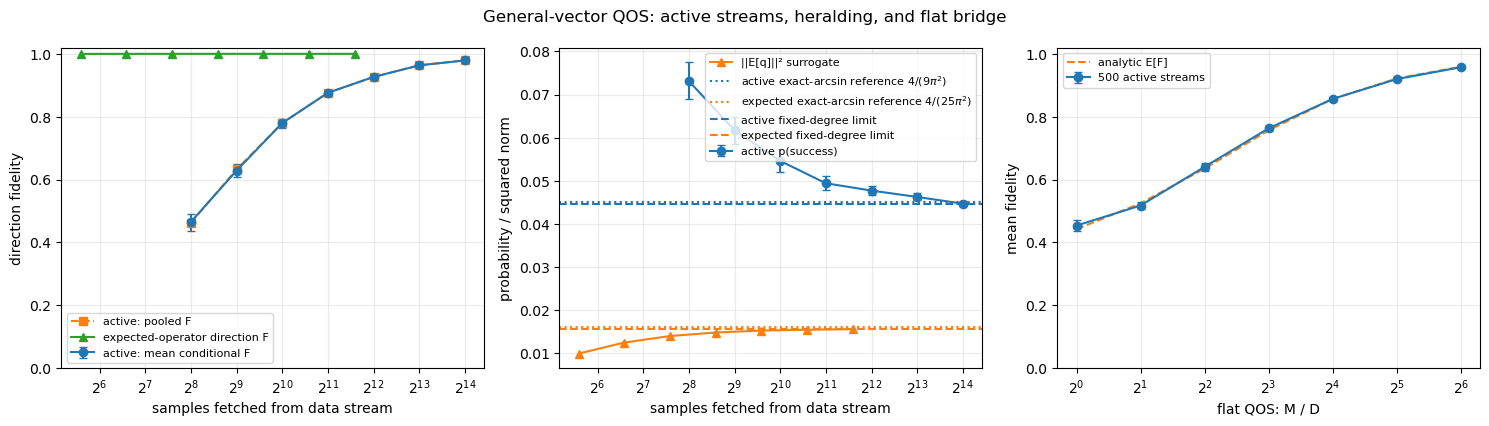

In [6]:
expected_summary = (
    expected_df.groupby(
        ["unit_samples", "M_fetched", "M_used"], as_index=False
    )
    .agg(
        mean_fidelity=("conditional_direction_fidelity", "mean"),
        fidelity_std=("conditional_direction_fidelity", "std"),
        mean_norm2=("success_norm2_surrogate", "mean"),
        norm2_std=("success_norm2_surrogate", "std"),
    )
)

def fixed_degree_limit_norm2(vector, random_signs, scale):
    walsh = hadamard_sign_matrix(len(vector))
    phase = (random_signs * vector) @ walsh / scale
    block = block_encoding_from_phase(np.exp(1j * phase))
    if scale == 3:
        sequence = np.repeat(
            block[None, :, :, :],
            len(QSVT_ANGLES) - 1,
            axis=0,
        )
        qsvt = apply_qsvt_imperfect(sequence)
    else:
        qsvt = apply_qsvt_diag(block)
    state = np.real(qsvt[0, 0]) / np.sqrt(len(vector))
    state = walsh @ state / np.sqrt(len(vector))
    state = random_signs * state
    return float(np.dot(state, state))


limit_rng = np.random.default_rng(SEED + 4)
limit_signs = [
    limit_rng.choice([-1.0, 1.0], size=dim)
    for _ in range(256)
]
active_fixed_degree_limit = np.mean([
    fixed_degree_limit_norm2(vector, signs, 3)
    for signs in limit_signs
])
expected_fixed_degree_limit = np.mean([
    fixed_degree_limit_norm2(vector, signs, 5)
    for signs in limit_signs
])

fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))

axes[0].errorbar(
    active_summary["M_fetched"],
    active_summary["mean_fidelity"],
    yerr=np.vstack([
        active_summary["mean_fidelity"]
        - active_summary["fidelity_ci_low"],
        active_summary["fidelity_ci_high"]
        - active_summary["mean_fidelity"],
    ]),
    marker="o", capsize=3, label="active: mean conditional F",
)
axes[0].plot(
    active_summary["M_fetched"],
    active_summary["pooled_fidelity"],
    marker="s", linestyle="--", label="active: pooled F",
)
axes[0].plot(
    expected_summary["M_fetched"],
    expected_summary["mean_fidelity"],
    marker="^", label="expected-operator direction F",
)
axes[0].set_xscale("log", base=2)
axes[0].set_ylim(0, 1.02)
axes[0].set_xlabel("samples fetched from data stream")
axes[0].set_ylabel("direction fidelity")
axes[0].grid(alpha=0.25)
axes[0].legend(fontsize=8)

axes[1].errorbar(
    active_summary["M_fetched"],
    active_summary["mean_success_probability"],
    yerr=np.vstack([
        active_summary["mean_success_probability"]
        - active_summary["success_ci_low"],
        active_summary["success_ci_high"]
        - active_summary["mean_success_probability"],
    ]),
    marker="o", capsize=3, label="active p(success)",
)
axes[1].plot(
    expected_summary["M_fetched"],
    expected_summary["mean_norm2"],
    marker="^", label="||E[q]||² surrogate",
)
axes[1].axhline(
    4 / (9 * np.pi**2), color="C0", linestyle=":",
    label=r"active exact-arcsin reference $4/(9\pi^2)$",
)
axes[1].axhline(
    4 / (25 * np.pi**2), color="C1", linestyle=":",
    label=r"expected exact-arcsin reference $4/(25\pi^2)$",
)
axes[1].axhline(
    active_fixed_degree_limit, color="C0", linestyle="--",
    label="active fixed-degree limit",
)
axes[1].axhline(
    expected_fixed_degree_limit, color="C1", linestyle="--",
    label="expected fixed-degree limit",
)
axes[1].set_xscale("log", base=2)
axes[1].set_xlabel("samples fetched from data stream")
axes[1].set_ylabel("probability / squared norm")
axes[1].grid(alpha=0.25)
axes[1].legend(fontsize=8)

axes[2].errorbar(
    flat_df["M_over_D"],
    flat_df["empirical_mean_fidelity"],
    yerr=1.96 * flat_df["empirical_sem"],
    marker="o", capsize=3, label="500 active streams",
)
axes[2].plot(
    flat_df["M_over_D"],
    flat_df["exact_mean_fidelity"],
    linestyle="--", label="analytic E[F]",
)
axes[2].set_xscale("log", base=2)
axes[2].set_ylim(0, 1.02)
axes[2].set_xlabel("flat QOS: M / D")
axes[2].set_ylabel("mean fidelity")
axes[2].grid(alpha=0.25)
axes[2].legend(fontsize=8)

fig.suptitle("General-vector QOS: active streams, heralding, and flat bridge")
fig.tight_layout()
figure_path = FIGURES / "general-vector-qos-scaling.png"
fig.savefig(figure_path, dpi=180, bbox_inches="tight")
plt.show()

![General-vector QOS scaling](../assets/figures/general-vector-qos-scaling.png)

关键读法：

- active 条件方向保真度确实随样本数上升；
- 主横轴使用真正从数据流取得的 $M_{\rm fetched}$；其中固定源码有 25% 
  未进入 QSVT，$M_{\rm used}$ 保留在 CSV；
- active 误差条来自 2,000 次 stream-level bootstrap 95% 区间；
- 但成功率只有约几个百分点，不能隐藏后选择成本；
- expected 的 $\|\mathbb E q\|^2$ 只是平均算子分支范数，不是真随机线路
  的平均成功率；
- 点线是精确 arcsin 的理想参考，虚线才是当前固定 degree-4 多项式的数值极限；
- flat-QOS 的 Monte Carlo 曲线与解析 $\mathbb E[F]$ 对齐。

## 4. 四个必须公开的源码陷阱

### 4.1 active 路径的 double norm

固定源码先做 `sampled_values /= norm`，又令 $t=D/(3\,norm)$。
所以若直接输入 $cb$，相位会多缩小 $1/c$，不具尺度不变性。源码测试使用
$\|b\|=1$，恰好遮住了问题。本章公开 wrapper 先把输入规范化，再进入忠实
core。

### 4.2 四组样本只使用三组

degree-4 角序列有 4 个 phase angles，却只有 3 次 signal-block 调用。固定源码
抽取 $4m$ 个样本、构造 4 组，然后传入 `blocks[:-1]`，因此：

$$
M_{\rm used}=\frac34M_{\rm fetched}.
$$

### 4.3 expected 与 active 不是同一配置

expected 使用 $D_0/(5r)$，active 使用 $D/(3r)$，padding 规则也不同。
若 QSVT 精确实现 arcsin，二者成功率参考值分别约为
$4/(25\pi^2)$ 与 $4/(9\pi^2)$；当前固定 degree-4 多项式的真实极限略有
偏离，已在图中单独画出。不能把这些常数差异解释成一种方法优于另一种。

### 4.4 padding leakage

expected 路径会把非二次幂维数补到下一个二次幂，最后直接切掉 padded
amplitudes。有限样本时它们不一定为零。本章同时保存 raw padding mass 与其占
完整 success branch 的比例，不能静默当成成功态的一部分。

In [7]:
audit_rng = np.random.default_rng(SEED + 2)
audit_vector = audit_rng.normal(size=16)
audit_indices = audit_rng.integers(0, 16, size=4096)
audit_signs = audit_rng.choice([-1.0, 1.0], size=16)

raw_a = sampled_general_vector_qos_source(
    audit_vector, audit_indices, audit_signs
)["state"]
raw_b = sampled_general_vector_qos_source(
    7 * audit_vector, audit_indices, audit_signs
)["state"]
fixed_a = sampled_general_vector_qos(
    audit_vector, audit_indices, audit_signs
)["state"]
fixed_b = sampled_general_vector_qos(
    7 * audit_vector, audit_indices, audit_signs
)["state"]

padding_result = expected_general_vector_qos(
    audit_vector[:10],
    unit_samples=64,
    random_signs=audit_signs[:16],
)

audit = {
    "raw_source_scale_change_l2": float(np.linalg.norm(raw_a - raw_b)),
    "normalized_wrapper_scale_change_l2": float(
        np.linalg.norm(fixed_a - fixed_b)
    ),
    "source_unused_sample_fraction_degree4": 0.25,
    "padding_example_original_dimension": 10,
    "padding_example_power_of_two_dimension": 16,
    "padding_leakage": padding_result["padding_leakage"],
    "padding_fraction_of_full_success": float(
        padding_result["padding_leakage"]
        / np.dot(
            padding_result["full_state"],
            padding_result["full_state"],
        )
    ),
    "max_active_block_unitarity_error": float(
        active_df["block_unitarity_error"].max()
    ),
    "max_abs_phase_used": float(
        active_df["max_abs_phase_used"].max()
    ),
    "max_abs_phase_discarded": float(
        active_df["max_abs_phase_discarded"].max()
    ),
    "max_signal_outside_fit_fraction_used": float(
        active_df["signal_outside_fit_fraction_used"].max()
    ),
    "max_phase_branch_ambiguity_fraction_used": float(
        active_df["phase_branch_ambiguity_fraction_used"].max()
    ),
    "qsvt_grid_max_abs_error": qsvt_max_error,
    "active_fixed_degree_limit_norm2": active_fixed_degree_limit,
    "expected_fixed_degree_limit_norm2":
        expected_fixed_degree_limit,
}
(RESULTS / "general_vector_source_audit.json").write_text(
    json.dumps(audit, indent=2), encoding="utf-8"
)
audit

{'raw_source_scale_change_l2': 0.04481010562828312,
 'normalized_wrapper_scale_change_l2': 6.664589960562512e-17,
 'source_unused_sample_fraction_degree4': 0.25,
 'padding_example_original_dimension': 10,
 'padding_example_power_of_two_dimension': 16,
 'padding_leakage': 8.088549833906657e-07,
 'padding_fraction_of_full_success': 5.2156927811254854e-05,
 'max_active_block_unitarity_error': 2.4974002836390025e-16,
 'max_abs_phase_used': 2.0556890509367007,
 'max_abs_phase_discarded': 1.6386898477210812,
 'max_signal_outside_fit_fraction_used': 0.06770833333333333,
 'max_phase_branch_ambiguity_fraction_used': 0.005208333333333333,
 'qsvt_grid_max_abs_error': 0.005304370940100611,
 'active_fixed_degree_limit_norm2': np.float64(0.04471387645378175),
 'expected_fixed_degree_limit_norm2': np.float64(0.015748642019639884)}

## 5. 一个样本在门级到底是什么

general-vector 的关键不是对地址 $|j\rangle$ 做多控制 projector。样本地址
$j$ 决定 Pauli string：

$$
Z^j=\bigotimes_{k:j_k=1} Z_k,\qquad
Z^j|u\rangle=(-1)^{j\cdot u}|u\rangle .
$$

在 signal ancilla 上控制后，每个样本贡献

$$
\exp(i\alpha_j Z_{\rm signal}Z^j).
$$

下面画出 $D=4$、样本地址 $j=3$ 的 parity-ladder 合成。它只需要
$2(w-1)$ 个 CX 和一个 $R_Z$，其中 $w$ 是包含 signal 后的 Pauli
string weight。这个单样本门是 full general-vector QSVT 的真实硬件积木，
但它本身还不是完整 state-preparation 电路。特别地，$j=0$ 时地址 Pauli
string 是 identity，样本仍是 signal 上可观测的 $R_Z(-2\alpha)$；在受控
multiplexor 中不能当作无关 global phase 删除。

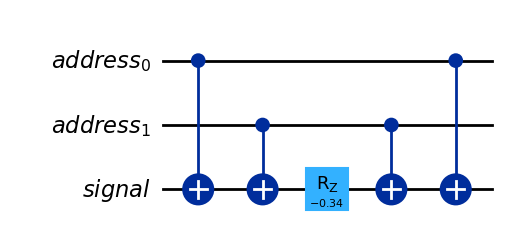

In [8]:
def pauli_sample_rotation_circuit(sample_address=3, alpha=0.17):
    address = QuantumRegister(2, "address")
    signal = QuantumRegister(1, "signal")
    circuit = QuantumCircuit(address, signal)
    active_address_qubits = [
        bit for bit in range(2)
        if (sample_address >> bit) & 1
    ]
    pivot = signal[0]
    for bit in active_address_qubits:
        circuit.cx(address[bit], pivot)
    circuit.rz(-2 * alpha, pivot)
    for bit in reversed(active_address_qubits):
        circuit.cx(address[bit], pivot)
    return circuit


sample_circuit = pauli_sample_rotation_circuit()
sample_figure = sample_circuit.draw(
    output="mpl",
    fold=-1,
    style={"displaytext": {"rz": "RZ"}},
)
sample_figure.savefig(
    CIRCUITS / "general-vector-pauli-sample.png",
    dpi=180, bbox_inches="tight",
)
sample_circuit.draw(output="mpl", fold=-1)

![General-vector sample rotation](../assets/circuits/general-vector-pauli-sample.png)

## 6. 本章结论与下一步

本章已经得到“真正运行的 general-vector QOS 数组结果”：

- active stream 的 signal blocks 都是严格 unitary；
- $D=64$ 上条件方向保真度随 $M$ 收敛；
- 后选择成功率单独报告，并没有被条件归一化藏掉；
- expected/active 的源码差异、double norm、25% 未使用样本与 padding leakage
  均已落盘；
- 单样本 Pauli-string rotation 给出了可编译门级映射。

仍不能把它称为完整 IMDb quantum classifier。下一章会真正训练官方 IMDb
分类器，并把学得的非平坦权重 $w$ 送进这里的 general-vector QOS，再用
QOS 重建权重在官方 held-out test 上重新分类。训练本身仍是经典的；完整量子
LS-SVM 还需要矩阵 block encoding、ridge/QSVT solver、amplitude
amplification 与读出。